# 1. Очистка данных

#### Загрузка датасета

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/Кирилл/Desktop/Kaggle Datasets/Retail Store Sales Dirty for Data Cleaning/retail_store_sales.csv')
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


#### Посмотрим размер датасета и количество пропусков

In [54]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


(None,
 Transaction ID         0
 Customer ID            0
 Category               0
 Item                1213
 Price Per Unit       609
 Quantity             604
 Total Spent          604
 Payment Method         0
 Location               0
 Transaction Date       0
 Discount Applied    4199
 dtype: int64)

#### Преобразуем типы данных

In [55]:
# Transaction Date в datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
# Discount Applied в boolean
df['Discount Applied'] = df['Discount Applied'].astype('boolean')

#### Проверим логику Total Spent

In [56]:
# Создаем колонку пересчитанной суммы
df['calc_total'] = df['Price Per Unit'] * df['Quantity']
# Проверяем расхождения
(df['Total Spent'] - df['calc_total']).abs().describe()

count    11362.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

#### Почистим пропуски

In [57]:
# Выведем столбцы в которых есть пропущенные значения
null_counts = df.isna().sum().sort_values(ascending=False)
print(null_counts[null_counts > 0])

Discount Applied    4199
Item                1213
calc_total          1213
Price Per Unit       609
Total Spent          604
Quantity             604
dtype: int64


In [58]:
print(f'Процент пропущенных значений Total Spent: {df['Total Spent'].isna().sum() / len(df) * 100.0}')
print(f'Процент пропущенных значений Price Per Unit: {df['Price Per Unit'].isna().sum() / len(df) * 100.0}')
print(f'Процент пропущенных значений Quantity: {df['Quantity'].isna().sum() / len(df) * 100.0}')
print(f'Процент пропущенных значений Discount Applied: {df['Discount Applied'].isna().sum() / len(df) * 100.0}')
print(f'Процент пропущенных значений Item: {df['Item'].isna().sum() / len(df) * 100.0}')

Процент пропущенных значений Total Spent: 4.8031809145129225
Процент пропущенных значений Price Per Unit: 4.842942345924453
Процент пропущенных значений Quantity: 4.8031809145129225
Процент пропущенных значений Discount Applied: 33.39165009940358
Процент пропущенных значений Item: 9.646123260437376


#### Записи с пропусками в Quantity и Total Spent, необходимо удалить, мы не можем заполнить их средними значениями или вычислить одно через другое, так как данных нет в обоих столбцах сразу. Без этих показателей строки бессмысленны.

In [59]:
# Удаляем строки с пропусками в Total Spent и Quantity
df.dropna(subset=['Total Spent', 'Quantity'], how='all', inplace=True)

In [60]:
null_counts = df.isna().sum().sort_values(ascending=False)
print(null_counts[null_counts > 0])

Discount Applied    3988
Item                 609
Price Per Unit       609
calc_total           609
dtype: int64


#### Строки с пропусками в Price Per Unit можно рассчитать: *Price Per Unit = Total Spent / Quantity*

In [61]:
# Для начала найдем такие строки
missing_price_rows = df[
    (df["Price Per Unit"].isna()) &
    (df["Total Spent"].notna()) &
    (df["Quantity"].notna())
]

missing_price_rows

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,calc_total
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,<NA>,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True,NaN
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,<NA>,NaN
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,<NA>,NaN
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
12435,TXN_5147764,CUST_01,Furniture,NaN,NaN,5.0,32.5,Credit Card,Online,2023-09-06,True,NaN
12457,TXN_1352194,CUST_17,Electric household essentials,NaN,NaN,4.0,86.0,Credit Card,Online,2023-02-26,<NA>,NaN
12477,TXN_5625684,CUST_22,Computers and electric accessories,NaN,NaN,4.0,80.0,Cash,In-store,2022-11-09,True,NaN
12491,TXN_7894525,CUST_23,Butchers,NaN,NaN,1.0,26.0,Credit Card,Online,2023-01-31,True,NaN


In [62]:
# Восстановим Price Per Unit
df.loc[df['Price Per Unit'].isna(), 'Price Per Unit'] = df['Total Spent'] / df['Quantity']
# Проверим результат
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                 609
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3988
calc_total           609
dtype: int64

In [63]:
# Смотрим, в каких категориях чаще всего встречаются пропуски в Item
df[df['Item'].isna()].groupby('Category').size().sort_values(ascending=False)

Category
Milk Products                         88
Food                                  81
Computers and electric accessories    80
Electric household essentials         79
Butchers                              75
Patisserie                            72
Beverages                             69
Furniture                             65
dtype: int64

#### Заполним пропуски в Item 

In [64]:
df['Item'] = df['Item'].fillna('Unknown')

In [65]:
df['Total Spent'].describe()

count    11971.000000
mean       129.652577
std         94.750697
min          5.000000
25%         51.000000
50%        108.500000
75%        192.000000
max        410.000000
Name: Total Spent, dtype: float64

#### Правостороння асимметрия в Total Spent, построим графики.

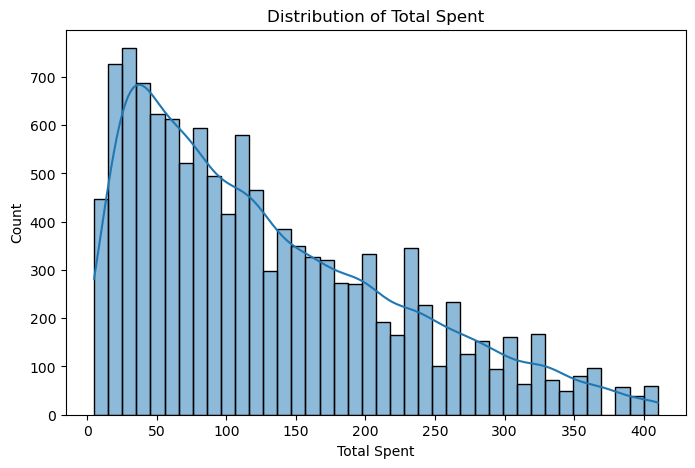

In [66]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Spent'], bins=40, kde=True)
plt.title('Distribution of Total Spent')
plt.show()

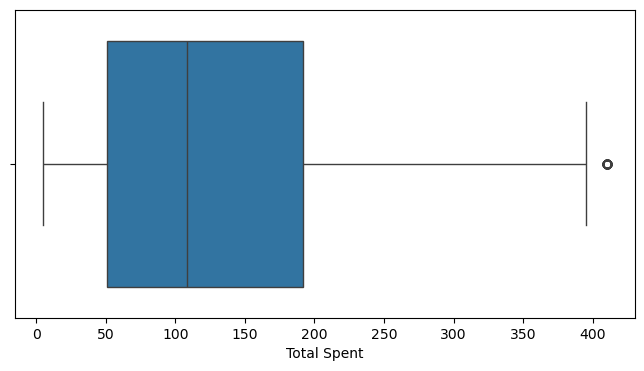

In [67]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total Spent'])
plt.show()

#### Поищем выбросы (IQR метод)

In [68]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Total Spent"] < lower_bound) | (df["Total Spent"] > upper_bound)]

outliers.shape

(60, 12)

In [69]:
# Посмотрим процент выбросов
len(outliers) / len(df)

0.005012112605463203

#### Так как выбросов меньше *1%* их можно удалить.

In [70]:
df = df[(df["Total Spent"] >= lower_bound) & (df["Total Spent"] <= upper_bound)]

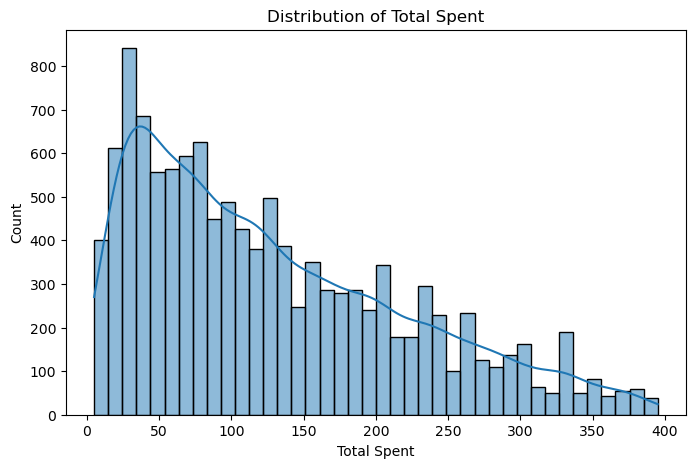

In [71]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Spent'], bins=40, kde=True)
plt.title('Distribution of Total Spent')
plt.show()

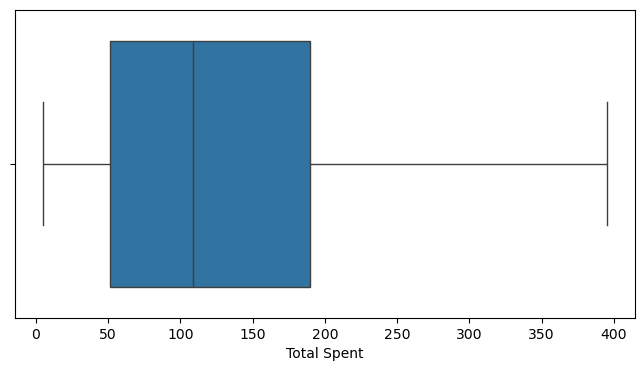

In [72]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total Spent'])
plt.show()

In [73]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,calc_total
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,185.0
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,261.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,43.0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,<NA>,247.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,87.5
...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,<NA>,152.0
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,58.5
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,<NA>,140.0
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,84.0


#### Найдем медианную цену Price Per Unit для каждого Item
#### Сравним эту цену в строке с пропуском с медианой
#### Если цена в строке с пропуском заметно ниже медианной, то там скорее всего была скидка, которую забыли отметить

In [74]:
# Считаем медианную цену для каждого товара (Item)
ref_prices = df.groupby('Item')['Price Per Unit'].median().to_dict()

# Функция для определения, была ли скидка на самом деле
def detect_hidden_discount(row):
    # Если значение уже есть (True/False), оставляем как есть
    if pd.notna(row['Discount Applied']):
        return row['Discount Applied']

    # Берем эталонную цену для этого товара
    ref_price = ref_prices.get(row['Item'])
    current_price = row['Price Per Unit']

    if ref_price and current_price:
        # Если текущая цена ниже эталонной хотя бы на 5% — считаем это скидкой
        if current_price < (ref_price * 0.95):
            return True
    # В остальных случаях считаем, что скидки не было
    return False

# Применяем функцию к датасету
df.loc[:, 'Discount Applied'] = df.apply(detect_hidden_discount, axis=1)

print(f"Пропусков осталось: {df['Discount Applied'].isna().sum()}")
print(df['Discount Applied'].value_counts())

Пропусков осталось: 0
Discount Applied
False    7830
True     4081
Name: count, dtype: Int64


---

# 2. Разведочный анализ данных (EDA)

In [75]:
df = df.drop(columns=['calc_total'])

In [76]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


#### Посмотрим популярность категорий

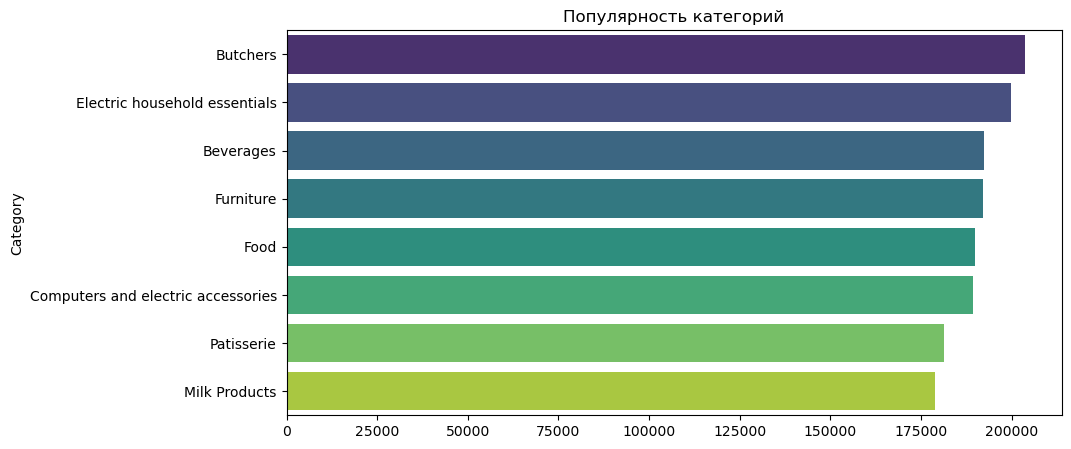

In [77]:
top_categories = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis')
plt.title('Популярность категорий')
plt.show()

#### Сравним способы оплаты (Online vs In-store)

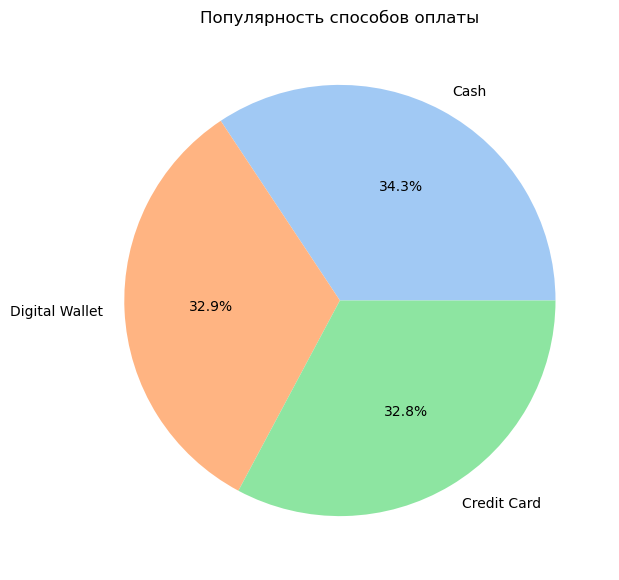

In [78]:
plt.figure(figsize=(7, 7))
df['Payment Method'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Популярность способов оплаты')
plt.ylabel('')
plt.show()

In [79]:
# Сравнение среднего чека: Онлайн vs Офлайн
avg_spent = df.groupby('Location')['Total Spent'].mean()
print(f'Средний чек: \n{avg_spent}')

Средний чек: 
Location
In-store    127.377384
Online      129.079483
Name: Total Spent, dtype: float64


#### Действительно ли люди покупают больше товаров (Quantity), когда есть скидка

C:\Users\Кирилл\AppData\Local\Temp\ipykernel_7296\1196696152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount Applied', y='Quantity', data=df, palette='Set2')


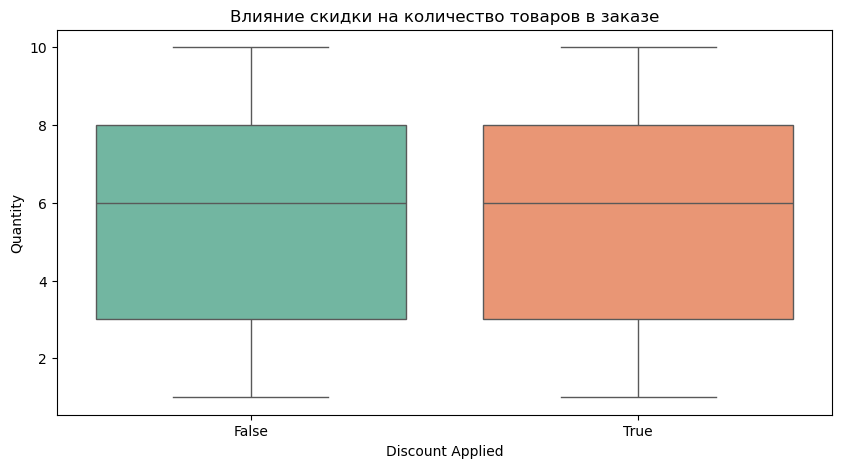

In [80]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Discount Applied', y='Quantity', data=df, palette='Set2')
plt.title('Влияние скидки на количество товаров в заказе')
plt.show()

#### Популярность категорий в зависимости от локации (Online vs In-store)

<Figure size 1200x600 with 0 Axes>

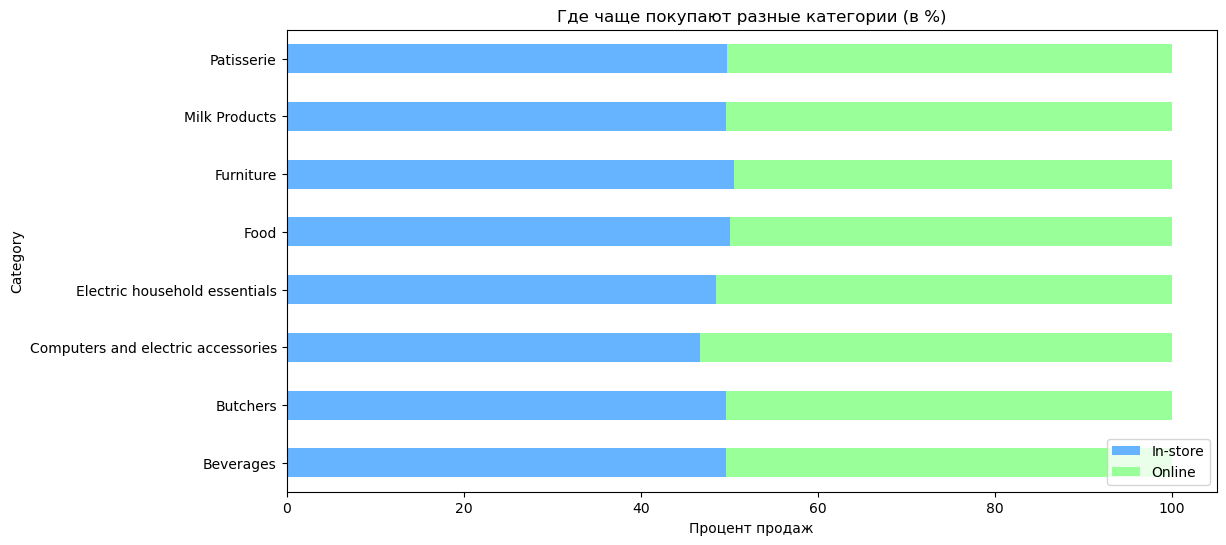

In [81]:
plt.figure(figsize=(12, 6))
ct = pd.crosstab(df['Category'], df['Location'], normalize='index') * 100
ct.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#66b3ff','#99ff99'])
plt.title('Где чаще покупают разные категории (в %)')
plt.xlabel('Процент продаж')
plt.legend(loc='lower right')
plt.show()

#### Расчет среднего чека со скидкой и без

In [82]:
print("Средний чек в зависимости от скидки:")
print(df.groupby('Discount Applied')['Total Spent'].mean())

Средний чек в зависимости от скидки:
Discount Applied
False    128.537867
True     127.669566
Name: Total Spent, dtype: float64


#### Топ-10 клиентов по сумме трат

In [83]:
top_customers = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False).head(10)
print("Топ-10 клиентов:\n", top_customers)

Топ-10 клиентов:
 Customer ID
CUST_24    67222.0
CUST_05    66564.5
CUST_08    66121.5
CUST_13    64217.0
CUST_23    63687.0
CUST_16    63110.5
CUST_10    62745.5
CUST_15    62707.5
CUST_21    61703.0
CUST_20    61123.0
Name: Total Spent, dtype: float64


#### Есть ли разница в среднем чеке между буднями и выходными?

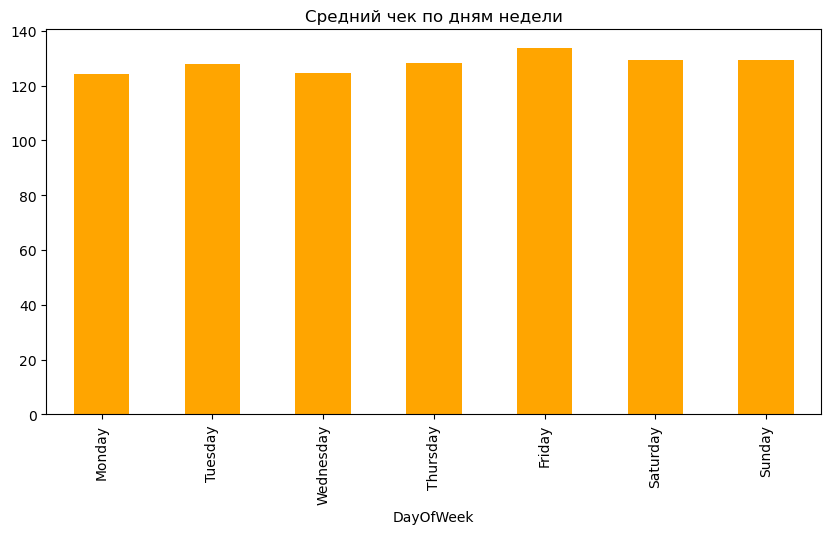

In [84]:
df['DayOfWeek'] = df['Transaction Date'].dt.day_name()
avg_day = df.groupby('DayOfWeek')['Total Spent'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
avg_day.plot(kind='bar', color='orange', figsize=(10, 5))
plt.title('Средний чек по дням недели')
plt.show()